<a href="https://colab.research.google.com/github/sriranjani-vs/Unsupervised-Learning-Practice/blob/main/Winedataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Performed Elbowmethod using Winedataset


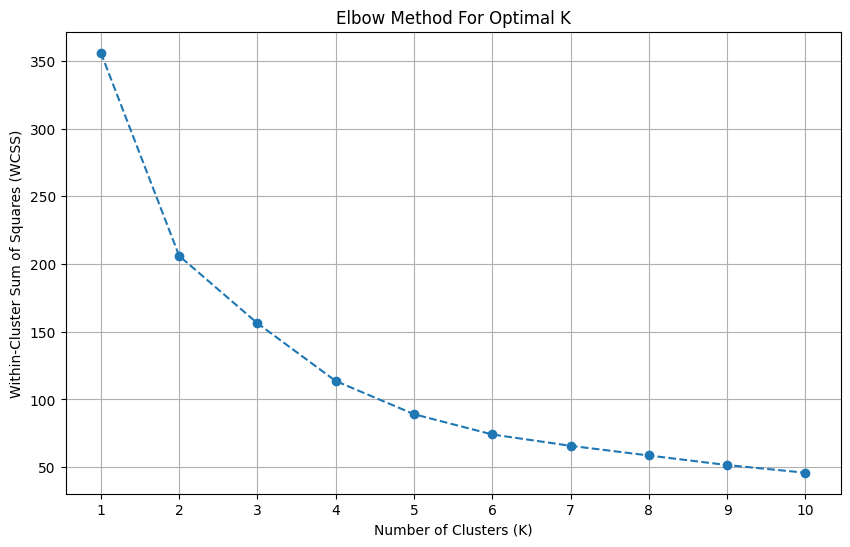

In [1]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd # Import pandas

# Load df and define X within this cell to ensure it's available
df = pd.read_csv("/content/Wine dataset.csv")
X = df.iloc[:, [3, 4]].copy() # Use .copy() to avoid SettingWithCopyWarning
X.columns = ["Annual Income","Spending Score"]

# Handle missing values in X by dropping rows with NaNs
X.dropna(inplace=True)

# Scale X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
# Try K from 1 to 10
for i in range(1, 11):
    # Renamed the instance variable to avoid shadowing the KMeans class
    kmeans_model = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans_model.fit(X_scaled)
    wcss.append(kmeans_model.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()